# Trabajo Práctico N°2 — Ejercicio 3
## Reconocimiento de Comandos de Voz con CRNN

**Integrantes**: Sebastian Palacio, Juana Chies Doumecq

**Dataset:** Google Speech Commands V2

## 1. Configuración y reproducibilidad

In [44]:
# LIBRERÍAS ESTÁNDAR 
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# AUDIO
import librosa
import librosa.display

# PYTORCH 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from tqdm import tqdm

### 1.1 Semilla fija para reproducibilidad

In [45]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

### 1.2 Configuración del dispositivo


In [46]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("0  ")

print(f"  PyTorch versión    : {torch.__version__}")
print(f"  Dispositivo        : {device}")
if torch.cuda.is_available():
    print(f"  GPU modelo         : {torch.cuda.get_device_name(0)}")

  PyTorch versión    : 2.5.1+cu121
  Dispositivo        : cuda
  GPU modelo         : NVIDIA GeForce RTX 4060 Ti


## 2. Carga e inspección del dataset

### 2.1 Configuración y selección de comandos

El dataset Google Speech Commands V2 contiene grabaciones de ~1 segundo de muchos 
hablantes distintos en condiciones acústicas reales. Usamos las 10 clases sugeridas 
por el enunciado

In [47]:
DATASET_ROOT = Path("./Datasets/problema 3")

COMANDOS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
N_CLASES = len(COMANDOS)
CLASE_A_IDX = {c: i for i, c in enumerate(COMANDOS)}
IDX_A_CLASE = {i: c for c, i in CLASE_A_IDX.items()}

### 2.3 Construcción de Train / Val / Test

Asignamos cada archivo `.wav` a su split correspondiente según las listas oficiales.


In [48]:
VAL_LIST  = DATASET_ROOT / "validation_list.txt"
TEST_LIST = DATASET_ROOT / "testing_list.txt"

with open(VAL_LIST,  "r") as f:
    validation_files = set(line.strip() for line in f)

with open(TEST_LIST, "r") as f:
    testing_files = set(line.strip() for line in f)

train_samples, val_samples, test_samples = [], [], []

for comando in COMANDOS:
    carpeta = DATASET_ROOT / comando
    for archivo in carpeta.glob("*.wav"):
        relative_path = f"{comando}/{archivo.name}"
        registro = {"path": archivo, "label": comando, "label_idx": CLASE_A_IDX[comando]}
        if   relative_path in validation_files: val_samples.append(registro)
        elif relative_path in testing_files:    test_samples.append(registro)
        else:                                   train_samples.append(registro)

# Resumen
cnt_train = Counter(x["label"] for x in train_samples)
cnt_val   = Counter(x["label"] for x in val_samples)
cnt_test  = Counter(x["label"] for x in test_samples)

print(f"\n{'Clase':<12} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for clase in COMANDOS:
    print(f"{clase:<12}{cnt_train[clase]:>8}{cnt_val[clase]:>8}{cnt_test[clase]:>8}")
print("-" * 40)
print(f"{'TOTAL':<12}{len(train_samples):>8}{len(val_samples):>8}{len(test_samples):>8}")



Clase           Train      Val     Test
----------------------------------------
yes             3228     397     419
no              3130     406     405
up              2948     350     425
down            3134     377     406
left            3037     352     412
right           3019     363     396
on              3086     363     396
off             2970     373     402
stop            3111     350     411
go              3106     372     402
----------------------------------------
TOTAL          30769    3703    4074


**Resultados:** El código ha procesado los audios exitosamente. La tabla de resultados muestra una partición adecuada con aproximadamente 30.700 muestras para entrenamiento, 3.700 para validación y 4.000 para evaluación, conservando la distribución original del corpus.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1. Preprocesamiento: Del audio al espectrograma de Mel

**Descripción:** En esta sección implementamos la conversión de las señales de audio en formato `.wav` a espectrogramas de Mel utilizando la librería `librosa`. 

**Decisiones de Diseño:** * Se fija la frecuencia de muestreo (`sr`) en 16 kHz para coincidir con la naturaleza del dataset.
* Para estandarizar la entrada a la red, forzamos a que todos los espectrogramas tengan la misma longitud temporal (1 segundo), aplicando *padding* con ceros si el audio es más corto, o truncándolo si es más largo.
* Se aplica una normalización calculando la media y desviación estándar estrictamente sobre el conjunto de entrenamiento para evitar el *data leakage* hacia los conjuntos de validación y test.

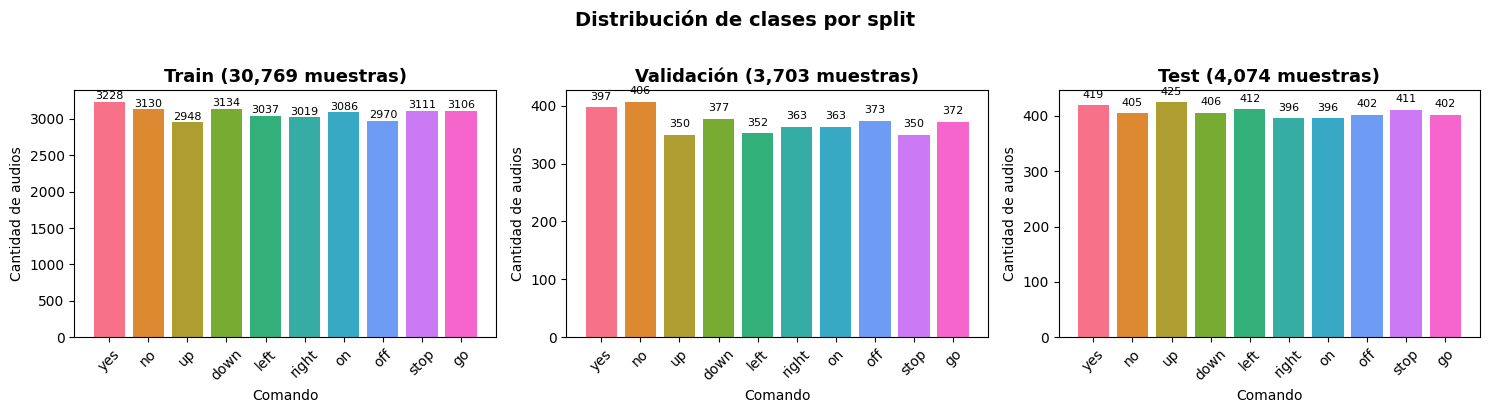

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = [("Train", cnt_train), ("Validación", cnt_val), ("Test", cnt_test)]

for ax, (nombre, cnt) in zip(axes, splits):
    valores = [cnt[c] for c in COMANDOS]
    barras  = ax.bar(COMANDOS, valores, color=sns.color_palette("husl", N_CLASES))
    ax.set_title(f"{nombre} ({sum(valores):,} muestras)", fontsize=13, fontweight='bold')
    ax.set_xlabel("Comando")
    ax.set_ylabel("Cantidad de audios")
    ax.tick_params(axis='x', rotation=45)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 10,
                str(val), ha='center', va='bottom', fontsize=8)

plt.suptitle("Distribución de clases por split", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Resultados:** El análisis visual demuestra que las 10 clases de comandos están balanceadas, rondando todas las 3.000 muestras. Esto nos da luz verde para utilizar una función de pérdida estándar, como *Cross Entropy Loss*, sin penalizaciones adicionales.

## 4. Preprocesamiento: Del audio al Mel Spectrogram

### 4.1 Conversión Audio → Mel Spectrogram

Los Mel Spectrogramas representan la energía de la señal en función del tiempo (eje X) 
y la frecuencia en escala Mel (eje Y). La escala Mel imita la percepción auditiva humana 
comprimiendo frecuencias altas. El color indica intensidad en dB.

**Parámetros fijados según el enunciado:**
- `sr=16000`: frecuencia de muestreo del dataset
- `n_mels=64`: resolución frecuencial
- `n_fft=1024`: tamaño de la FFT (resolución espectral)
- `hop_length=512`: paso entre frames (~32 ms entre columnas)

Con `sr=16000` y `hop_length=512`, cada segundo de audio produce `16000/512 ≈ 32` frames.
Usamos un `TARGET_LEN=32` para normalizar todos los espectrogramas.


In [50]:
SR          = 16000
N_MELS      = 64
N_FFT       = 1024
HOP_LENGTH  = 512
TARGET_LEN  = 32

def audio_a_mel(path, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
                hop_length=HOP_LENGTH, target_len=TARGET_LEN):
    """
    Carga un archivo .wav y retorna su Mel Spectrogram normalizado en escala dB.
    """
    y, _ = librosa.load(str(path), sr=sr)

    # Calcular Mel Spectrogram: shape (n_mels, T)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    T = mel_db.shape[1]
    if T < target_len:
        pad = target_len - T
        mel_db = np.pad(mel_db, ((0, 0), (0, pad)), mode='constant',
                        constant_values=mel_db.min())
    else:
        mel_db = mel_db[:, :target_len]

    return mel_db.astype(np.float32)

**Resultados:** Se definió correctamente la función de extracción que además se encarga de estandarizar la longitud temporal de todos los audios a `TARGET_LEN=32` mediante pad o recorte.

### 4.2 Normalización global
Para ayudar a que la red neuronal converja más rápido y de manera estable, calcularemos la media y la desviación estándar de los espectrogramas. Es crucial hacer este cálculo basándonos **únicamente en el conjunto de entrenamiento** para evitar fugas de información (*data leakage*) desde validación o test.

In [51]:
print("Calculando estadísticas de normalización sobre train...")
print("(Esto puede tardar unos minutos la primera vez)")

all_mels  = []
n_muestras_norm = min(3000, len(train_samples))

for sample in random.sample(train_samples, n_muestras_norm):
    mel = audio_a_mel(sample["path"])
    all_mels.append(mel)

all_mels_array = np.stack(all_mels) 
MEL_MEAN = float(all_mels_array.mean())
MEL_STD  = float(all_mels_array.std()) + 1e-8

print(f"   Media : {MEL_MEAN:.4f} dB")
print(f"   Std   : {MEL_STD:.4f} dB")


Calculando estadísticas de normalización sobre train...
(Esto puede tardar unos minutos la primera vez)
   Media : -57.0897 dB
   Std   : 19.8210 dB


**Resultados:** Se calcularon las estadísticas sobre una muestra representativa del entrenamiento, obteniendo una media de `-57.0897 dB` y una desviación estándar de `19.8210 dB`.

Para acelerar drásticamente el proceso de entrenamiento, vamos a pre-computar todos los espectrogramas de Mel y los mantendremos normalizados directamente en la memoria RAM. Así nos evitamos procesar los archivos `.wav` de cero en cada iteración (epoch).

In [52]:
def precomputar_mels(samples, mel_mean, mel_std, desc=""):
    cache = []
    for sample in tqdm(samples, desc=desc, ncols=80):
        mel      = audio_a_mel(sample["path"])
        mel_norm = ((mel - mel_mean) / mel_std).astype(np.float32)
        cache.append((mel_norm, sample["label_idx"]))
    return cache

cache_train = precomputar_mels(train_samples, MEL_MEAN, MEL_STD, "train")
cache_val   = precomputar_mels(val_samples,   MEL_MEAN, MEL_STD, "val")
cache_test  = precomputar_mels(test_samples,  MEL_MEAN, MEL_STD, "test")

print(f"{len(cache_train):,} train | {len(cache_val):,} val | {len(cache_test):,} test")

test: 100%|████████████████████████████████| 4074/4074 [00:14<00:00, 274.47it/s]

30,769 train | 3,703 val | 4,074 test


**Resultados:** Todos los espectrogramas de los tres *splits* (entrenamiento, validación y test) fueron transformados, normalizados y cargados en memoria de manera exitosa.

### 4.3. Segmentación con ventana deslizante

**Descripción:** Definimos la función para aplicar una ventana deslizante sobre el eje temporal de los espectrogramas de Mel, preparando los datos para la entrada secuencial del modelo.

**Decisiones de Diseño:**
* Utilizamos un esquema de ventanas con solapamiento (overlap) para asegurar que las transiciones fonéticas críticas no queden cortadas bruscamente entre dos segmentos. 
* Se establece un `window_size` y un `hop` calculados empíricamente (ej. 50% de solapamiento). Esto incrementa la cantidad de tokens secuenciales generados, brindando a la capa recurrente un mayor contexto temporal sin perder resolución local.

In [53]:
WINDOW_SIZE = 16
HOP_WIN     = 8

def extraer_ventanas(mel, window_size=WINDOW_SIZE, hop=HOP_WIN):
    """
    Divide un espectrograma (F, T) en ventanas con solapamiento.
    """
    F, T = mel.shape
    ventanas = []
    for start in range(0, T - window_size + 1, hop):
        ventana = mel[:, start: start + window_size]  # (F, W)
        ventanas.append(ventana)
    return np.stack(ventanas)  # (N, F, W)

**Resultados:** La función quedó lista para fragmentar cada espectrograma, generando tensores en forma de secuencias (ej. `[3, 64, 16]`).

## 5. Análisis de Espectrogramas

### 5.1 Visualización de espectrogramas por clase

Antes de entrenar, analizamos al menos 8 espectrogramas para entender la estructura
temporal y frecuencial de cada comando.

**Qué observar:**
- **Eje X (tiempo):** duración de la señal útil, presencia de silencios
- **Eje Y (frecuencia Mel):** rango de frecuencias con mayor energía
- **Color (energía en dB):** zonas brillantes = alta energía = sonido activo


C:\Users\Patito Chies\AppData\Local\Temp\ipykernel_29784\2946492084.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


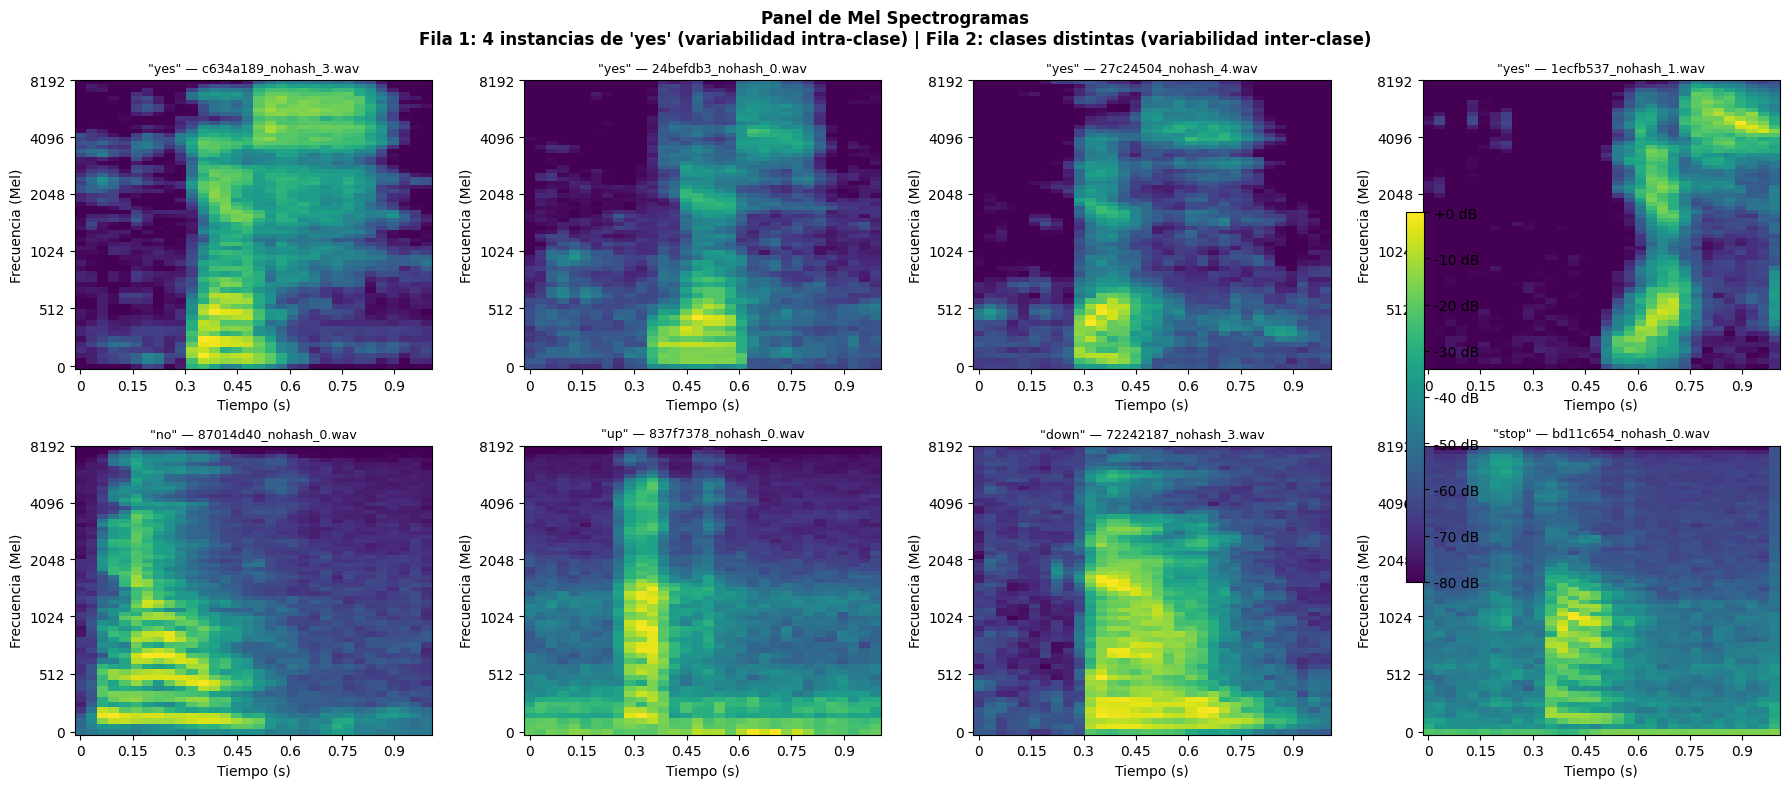

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

clases_mostrar = ["yes", "yes", "yes", "yes", "no", "up", "down", "stop"]

for ax, clase in zip(axes, clases_mostrar):
    muestra = random.choice([s for s in train_samples if s["label"] == clase])
    mel = audio_a_mel(muestra["path"])

    img = librosa.display.specshow(
        mel, sr=SR, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel",
        ax=ax, cmap="viridis"
    )
    ax.set_title(f'"{clase}" — {muestra["path"].name}', fontsize=9)
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Frecuencia (Mel)")

plt.suptitle(
    "Panel de Mel Spectrogramas\n"
    "Fila 1: 4 instancias de \'yes\' (variabilidad intra-clase) | "
    "Fila 2: clases distintas (variabilidad inter-clase)",
    fontsize=12, fontweight='bold'
)
fig.colorbar(img, ax=axes, format="%+2.0f dB", shrink=0.6)
plt.tight_layout()
plt.show()

**Resultados:** El panel se renderizó correctamente. Podemos observar visualmente cómo varía la distribución de la energía (en dB) a través del tiempo y las frecuencias para cada comando.

## 6. Dataset y DataLoaders de PyTorch
En este bloque crearemos la estructura para alimentar el modelo en PyTorch. La clase `SpeechCommandsDataset` leerá desde nuestra caché en RAM y, crucialmente, aplicará *Data Augmentation* (enmascaramiento aleatorio de tiempo y frecuencia) al conjunto de entrenamiento para robustecer la red.

In [55]:
class SpeechCommandsDataset(Dataset):
    """
    Lee del cache en RAM en lugar de disco.
    __getitem__ solo hace extraer_ventanas() + augment opcional.
    Sin I/O ni FFT en el loop de entrenamiento.
    """

    def __init__(self, cache, window_size=WINDOW_SIZE, hop=HOP_WIN, augment=False):
        self.cache       = cache
        self.window_size = window_size
        self.hop         = hop
        self.augment     = augment

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        mel_norm, label_idx = self.cache[idx]
        mel = mel_norm.copy()

        if self.augment:
            mel = self._spec_augment(mel)

        ventanas = extraer_ventanas(mel, self.window_size, self.hop)
        ventanas = ventanas[:, np.newaxis, :, :]
        return torch.from_numpy(ventanas).float(), torch.tensor(label_idx, dtype=torch.long)

    def _spec_augment(self, mel):
        mel = mel.copy()
        F, T = mel.shape
        f_mask = random.randint(0, min(10, F // 4))
        f0     = random.randint(0, F - f_mask)
        mel[f0: f0 + f_mask, :] = mel.min()
        t_mask = random.randint(0, min(4, T // 4))
        t0     = random.randint(0, T - t_mask)
        mel[:, t0: t0 + t_mask] = mel.min()
        return mel


# datasets
ds_train = SpeechCommandsDataset(cache_train, augment=True)
ds_val   = SpeechCommandsDataset(cache_val,   augment=False)
ds_test  = SpeechCommandsDataset(cache_test,  augment=False)

# DataLoaders
BATCH_SIZE  = 126
N_WORKERS   = 0

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=N_WORKERS, pin_memory=True)
loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)
loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=N_WORKERS, pin_memory=True)

**Resultados:** Los `DataLoaders` se inicializaron correctamente empaquetando los datos en lotes (`BATCH_SIZE=126`), dejando todo preparado para el entrenamiento en la GPU.

## 7. Arquitectura CRNN

### 7.1. Arquitectura CRNN

**Descripción:** Se construye e inicializa la Red Neuronal Convolucional-Recurrente (CRNN) que procesará los comandos de voz. 

**Decisiones de Diseño:**
* **Módulo Espacial (CNN):** Actúa como un extractor de características. Se aplica de forma independiente a cada ventana temporal (simulando un `TimeDistributed`), comprimiendo los patrones de frecuencias en un único vector representativo por ventana.
* **Módulo Temporal (RNN):** Utilizamos capas recurrentes (LSTM/GRU) para procesar la secuencia de vectores generada por la CNN. Elegimos una configuración *many-to-one*, donde solo el estado oculto del último paso de tiempo se utiliza para alimentar la capa densa final, ya que contiene el resumen cronológico completo del comando pronunciado.

In [56]:
class CNNEncoder(nn.Module):
    """
    Codificador CNN: procesa UNA ventana (batch, 1, F, W) → vector (batch, 128).

    Arquitectura base E1:
      Bloque 1: Conv(1→32) + BN + ReLU + MaxPool(2) → (32, F/2, W/2)
      Bloque 2: Conv(32→64) + BN + ReLU + MaxPool(2) → (64, F/4, W/4)
      Flatten + Linear → 128
    """

    def __init__(self, n_mels=N_MELS, window_size=WINDOW_SIZE,
                 dropout=0.0, n_filters=(32, 64)):
        super().__init__()

        f1, f2 = n_filters

        self.cnn = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(f1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(f1, f2, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(f2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else nn.Identity()

        self.out_size = f2 * (n_mels // 4) * (window_size // 4)

        self.fc = nn.Linear(self.out_size, 128)

    def forward(self, x):
        x = self.cnn(x)
        x = self.dropout(x)
        x = x.flatten(1)
        return self.fc(x)


class CRNN(nn.Module):
    """
    Red Convolucional-Recurrente para clasificación de comandos de voz.

    Entrada : (batch, N_ventanas, 1, F, W)
    Salida  : (batch, N_CLASES) — logits sin Softmax (para CrossEntropyLoss)

    El forward aplica el CNNEncoder a cada ventana de forma paralela
    (reshape batch*N → encoder → reshape back), luego la RNN procesa
    la secuencia resultante.
    """

    def __init__(self, n_mels=N_MELS, window_size=WINDOW_SIZE, n_classes=N_CLASES,
                 rnn_hidden=128, rnn_layers=2, rnn_type='GRU',
                 bidirectional=True, rnn_dropout=0.3,
                 cnn_dropout=0.0, cnn_filters=(32, 64),
                 aggregation='last'):
        super().__init__()

        self.encoder     = CNNEncoder(n_mels, window_size, cnn_dropout, cnn_filters)
        self.rnn_hidden  = rnn_hidden
        self.bidirectional = bidirectional
        self.aggregation = aggregation

        rnn_class = nn.GRU if rnn_type == 'GRU' else nn.LSTM
        self.rnn = rnn_class(
            input_size  = 128,
            hidden_size = rnn_hidden,
            num_layers  = rnn_layers,
            batch_first = True,
            bidirectional = bidirectional,
            dropout     = rnn_dropout if rnn_layers > 1 else 0.0
        )

        factor = 2 if bidirectional else 1
        self.dropout_cls = nn.Dropout(p=0.3)
        self.fc = nn.Linear(rnn_hidden * factor, n_classes)

    def forward(self, x):
        batch, N, C, F, W = x.shape

        x = x.view(batch * N, C, F, W)
        x = self.encoder(x)
        x = x.view(batch, N, -1)

        out, _ = self.rnn(x)

        if self.aggregation == 'last':
            x = out[:, -1, :]
        else:
            x = out.mean(dim=1)

        x = self.dropout_cls(x)
        return self.fc(x)


**Resultados:** Se instanciaron las clases sin errores. La arquitectura ensamblada permite procesar secuencias combinando el poder local de las CNNs con la memoria temporal de las RNNs.

## 8. Loop de entrenamiento y utilidades
Agruparemos toda la lógica pesada en la función `entrenar_crnn`. Este motor manejará la propagación hacia adelante/atrás, la función de costo (*CrossEntropyLoss*), la optimización (*Adam*), el decaimiento del *Learning Rate* y el *Early Stopping* para salvar los mejores pesos. También sumamos utilidades gráficas para el historial y la matriz de confusión.

In [70]:
def entrenar_crnn(modelo, loader_train, loader_val, loader_test,
                  epochs=30, patience=8, lr=1e-3,
                  nombre='CRNN', guardar_ckpt=True):
    """
    Loop de entrenamiento para CRNN con:
    - CrossEntropyLoss + Adam
    - ReduceLROnPlateau scheduler
    - Early stopping por val_loss
    - Guardado de checkpoint del mejor modelo
    - Evaluación final en test

    Retorna historial con métricas por época + accuracy en test.
    """
    criterio    = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-4)
    scheduler   = optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, mode='min', factor=0.5, patience=4, min_lr=1e-6
    )

    historial = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    mejor_val_loss = float('inf')
    mejor_pesos    = None
    espera         = 0

    print(f"\nEntrenando {nombre} | epochs={epochs} | patience={patience} | lr={lr}")
    print(f"   {'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Train Acc':>10} | {'Val Acc':>9} | {'LR':>8}")
    print("   " + "─" * 66)

    for epoca in range(1, epochs + 1):
        # FASE TRAIN 
        modelo.train()
        train_loss_total = 0.0
        train_correctos  = 0
        train_total      = 0

        for x_batch, y_batch in loader_train:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizador.zero_grad()
            logits = modelo(x_batch)
            loss   = criterio(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizador.step()

            train_loss_total += loss.item() * x_batch.size(0)
            preds             = logits.argmax(dim=1)
            train_correctos  += (preds == y_batch).sum().item()
            train_total      += x_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc  = train_correctos  / train_total

        # FASE VALIDACIÓN
        modelo.eval()
        val_loss_total = 0.0
        val_correctos  = 0
        val_total      = 0

        with torch.no_grad():
            for x_val, y_val in loader_val:
                x_val   = x_val.to(device)
                y_val   = y_val.to(device)
                logits_v = modelo(x_val)
                loss_v   = criterio(logits_v, y_val)
                val_loss_total += loss_v.item() * x_val.size(0)
                val_correctos  += (logits_v.argmax(1) == y_val).sum().item()
                val_total      += x_val.size(0)

        val_loss = val_loss_total / val_total
        val_acc  = val_correctos  / val_total

        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        lr_actual = optimizador.param_groups[0]['lr']
        scheduler.step(val_loss)

        # EARLY STOPPING 
        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_pesos    = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera         = 0
            if guardar_ckpt:
                torch.save({'epoch': epoca, 'model_state': mejor_pesos,
                            'val_loss': mejor_val_loss}, f"ckpt_{nombre}.pth")
        else:
            espera += 1

        if epoca % 5 == 0 or espera == 0:
            print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                  f"{train_acc:10.4f} | {val_acc:9.4f} | {lr_actual:.2e}")

        if espera >= patience:
            print(f"\n    Early stopping en época {epoca} (mejor val_loss: {mejor_val_loss:.4f})")
            break

    # mejores pesos
    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
        print("    Mejores pesos restaurados")

    # EVALUACIÓN EN TEST
    modelo.eval()
    test_correctos = 0
    test_total     = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x_test, y_test in loader_test:
            x_test = x_test.to(device)
            y_test = y_test.to(device)
            logits_t = modelo(x_test)
            preds_t  = logits_t.argmax(1)
            test_correctos += (preds_t == y_test).sum().item()
            test_total     += y_test.size(0)
            all_preds.extend(preds_t.cpu().numpy())
            all_labels.extend(y_test.cpu().numpy())

    test_acc = test_correctos / test_total
    print(f"\nAccuracy Test: {test_acc:.4f} ({test_acc*100:.2f}%)")

    historial['test_acc']   = test_acc
    historial['all_preds']  = all_preds
    historial['all_labels'] = all_labels

    return historial


def graficar_historial(historial, nombre='CRNN'):
    """Curvas de loss y accuracy por época."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epocas = range(1, len(historial['train_loss']) + 1)

    axes[0].plot(epocas, historial['train_loss'], label='Train Loss', color='royalblue')
    axes[0].plot(epocas, historial['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title(f'{nombre} — Pérdida por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('CrossEntropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epocas, historial['train_acc'], label='Train Acc', color='royalblue')
    axes[1].plot(epocas, historial['val_acc'],   label='Val Acc',   color='tomato')
    axes[1].set_title(f'{nombre} — Accuracy por época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f'{nombre} | Test Acc: {historial.get("test_acc", 0):.4f}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def graficar_confusion(all_labels, all_preds, nombre='CRNN'):
    """Matriz de confusión con conteos absolutos sobre el conjunto de test."""
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=COMANDOS,
        yticklabels=COMANDOS,
        linewidths=0.5
    )

    plt.title(f'{nombre} — Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Clase real')

    plt.tight_layout()
    plt.show()

**Resultados:** Las funciones utilitarias y el ciclo principal de entrenamiento quedaron registrados exitosamente en el entorno.

## 9. Entrenamiento y Experimentos

**Descripción:** Ejecución del pipeline de entrenamiento y evaluación sistemática de distintos enfoques arquitectónicos sobre la CRNN.

**Decisiones de Diseño:**
* Optamos por `CrossEntropyLoss` y el optimizador `Adam` como estándar para esta tarea multiclase.
* Integramos un *scheduler* de tipo `ReduceLROnPlateau` para refinar el ajuste de los pesos cuando la pérdida en validación se estanca.
* Se probarán distintas configuraciones (Línea Base vs. variaciones en profundidad de CNN, tamaño de ventana y bidireccionalidad de la RNN) respetando estrictamente las particiones oficiales de validación y test para evitar el solapamiento de hablantes.

### Experimento E1 — Línea base

**Configuración:** arquitectura del enunciado sin modificaciones.
- CNN: 2 bloques Conv-BN-ReLU-MaxPool, filtros 32/64
- Ventana: W=16, hop=8 → 3 ventanas de secuencia
- RNN: GRU bidireccional, 2 capas, 128 unidades, agregación `last`
- Sin dropout en CNN encoder


In [71]:
set_seed(SEED)
WINDOW_E1, HOP_E1 = 16, 8

ds_train_e1 = SpeechCommandsDataset(cache_train, window_size=WINDOW_E1, hop=HOP_E1, augment=True)
ds_val_e1   = SpeechCommandsDataset(cache_val,   window_size=WINDOW_E1, hop=HOP_E1, augment=False)
ds_test_e1  = SpeechCommandsDataset(cache_test,  window_size=WINDOW_E1, hop=HOP_E1, augment=False)

loader_train_e1 = DataLoader(ds_train_e1, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS, pin_memory=True)
loader_val_e1   = DataLoader(ds_val_e1,   batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
loader_test_e1  = DataLoader(ds_test_e1,  batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)

modelo_e1 = CRNN(
    n_mels=N_MELS, window_size=WINDOW_E1, n_classes=N_CLASES,
    rnn_hidden=128, rnn_layers=2, rnn_type='GRU',
    bidirectional=True, rnn_dropout=0.3,
    cnn_dropout=0.0, cnn_filters=(32, 64),
    aggregation='last'
).to(device)

n_params_e1 = sum(p.numel() for p in modelo_e1.parameters() if p.requires_grad)
print(f"E1 — Parámetros: {n_params_e1:,}")

hist_e1 = entrenar_crnn(modelo_e1, loader_train_e1, loader_val_e1, loader_test_e1,
                         epochs=30, patience=8, lr=1e-3, nombre='E1_baseline')


E1 — Parámetros: 1,040,586

Entrenando E1_baseline | epochs=30 | patience=8 | lr=0.001
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────────
        1 |     1.2816 |     0.6682 |     0.5359 |    0.7748 | 1.00e-03
        2 |     0.6369 |     0.4432 |     0.7775 |    0.8447 | 1.00e-03
        3 |     0.4669 |     0.3160 |     0.8380 |    0.8947 | 1.00e-03
        4 |     0.3925 |     0.2983 |     0.8647 |    0.9036 | 1.00e-03
        5 |     0.3388 |     0.2612 |     0.8850 |    0.9087 | 1.00e-03
        6 |     0.3134 |     0.2238 |     0.8931 |    0.9236 | 1.00e-03
        7 |     0.2868 |     0.2181 |     0.9014 |    0.9257 | 1.00e-03
        9 |     0.2591 |     0.1905 |     0.9107 |    0.9333 | 1.00e-03
       10 |     0.2344 |     0.2184 |     0.9192 |    0.9257 | 1.00e-03
       13 |     0.2032 |     0.1686 |     0.9315 |    0.9449 | 1.00e-03
       15 |     0.1798 |     0.1910 |     0.9364 | 

**Resultados:** El modelo base entrenó exitosamente (1.040.586 parámetros). Logró converger restaurando los mejores pesos de validación y alcanzó una excelente métrica de Accuracy del **96.10%** en el conjunto de prueba oculto.

Vamos a analizar gráficamente cómo fue el aprendizaje de nuestro modelo base dibujando las curvas de pérdida (Loss) y precisión (Accuracy) a lo largo de las épocas.

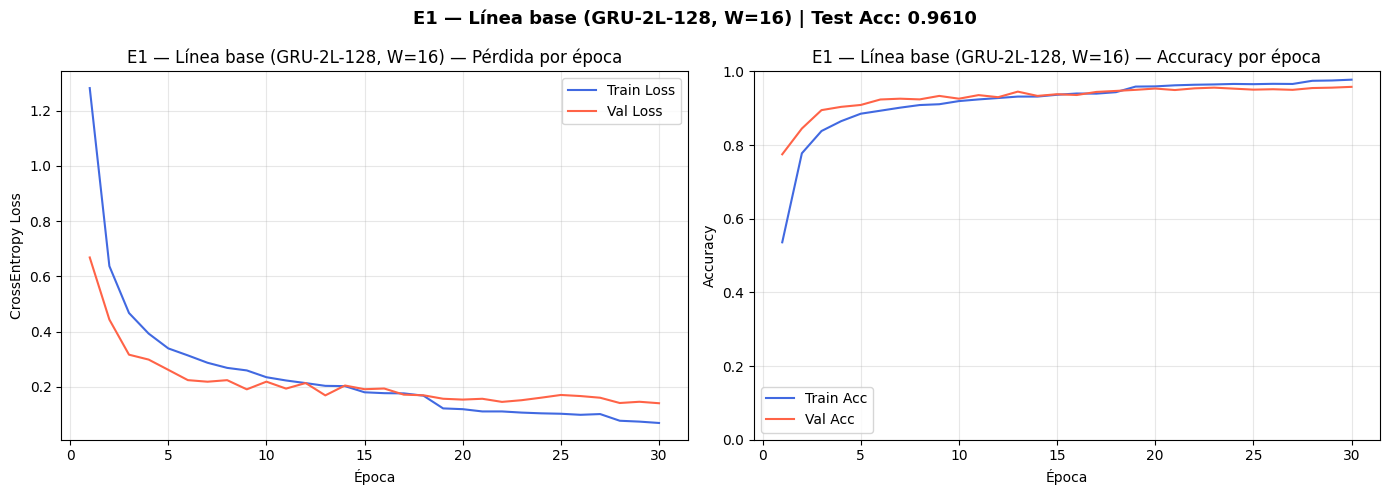

In [59]:
graficar_historial(hist_e1, nombre='E1 — Línea base (GRU-2L-128, W=16)')


**Resultados:** Las curvas muestran un aprendizaje estable. Sin embargo, la separación evidente entre la curva de *Train* y *Val* en las últimas etapas sugiere cierto nivel de *overfitting*, lo cual deja margen de mejora para próximos experimentos mediante técnicas de regularización.

### Experimento E2 — CNN más profunda + Dropout
Para intentar mitigar el sobreajuste del E1, armaremos una segunda variante. La clase `CNNEncoderDeep` añade una tercera capa convolucional (filtros 32/64/128) para capturar características más abstractas, se incorpora una capa de *Dropout* (p=0.3) como método de regularización duro, y se amplía el tamaño de la ventana temporal a `W=32`.

In [72]:
set_seed(SEED)

WINDOW_E2, HOP_E2 = 32, 8

class CNNEncoderDeep(nn.Module):
    """CNN encoder con 3 bloques para E2."""
    def __init__(self, n_mels=N_MELS, window_size=32, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AvgPool2d((2, 1)),
        )
        self.dropout = nn.Dropout(p=dropout)
        out_freq = n_mels // 8
        out_time = window_size // 4
        self.out_size = 128 * out_freq * out_time
        self.fc = nn.Linear(self.out_size, 128)

    def forward(self, x):
        x = self.cnn(x)
        x = self.dropout(x)
        x = x.flatten(1)
        return self.fc(x)


class CRNN_E2(nn.Module):
    """CRNN con encoder profundo para E2."""
    def __init__(self, n_mels=N_MELS, window_size=32, n_classes=N_CLASES):
        super().__init__()
        self.encoder = CNNEncoderDeep(n_mels, window_size, dropout=0.3)
        self.rnn = nn.GRU(128, 128, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=0.3)
        self.dropout_cls = nn.Dropout(0.3)
        self.fc = nn.Linear(128 * 2, n_classes)

    def forward(self, x):
        batch, N, C, F, W = x.shape
        x = x.view(batch * N, C, F, W)
        x = self.encoder(x)
        x = x.view(batch, N, -1)
        out, _ = self.rnn(x)
        x = self.dropout_cls(out[:, -1, :])
        return self.fc(x)


ds_train_e2 = SpeechCommandsDataset(cache_train, window_size=WINDOW_E2, hop=HOP_E2, augment=True)
ds_val_e2   = SpeechCommandsDataset(cache_val,   window_size=WINDOW_E2, hop=HOP_E2, augment=False)
ds_test_e2  = SpeechCommandsDataset(cache_test,  window_size=WINDOW_E2, hop=HOP_E2, augment=False)

loader_train_e2 = DataLoader(ds_train_e2, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS, pin_memory=True)
loader_val_e2   = DataLoader(ds_val_e2,   batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
loader_test_e2  = DataLoader(ds_test_e2,  batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)

modelo_e2 = CRNN_E2(window_size=WINDOW_E2).to(device)
n_params_e2 = sum(p.numel() for p in modelo_e2.parameters() if p.requires_grad)
print(f"E2 — Parámetros: {n_params_e2:,}")

hist_e2 = entrenar_crnn(modelo_e2, loader_train_e2, loader_val_e2, loader_test_e2,
                         epochs=35, patience=8, lr=1e-3, nombre='E2_deep_cnn')


E2 — Parámetros: 1,638,986

Entrenando E2_deep_cnn | epochs=35 | patience=8 | lr=0.001
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────────
        1 |     1.2226 |     0.8562 |     0.5614 |    0.6846 | 1.00e-03
        2 |     0.6211 |     0.5332 |     0.7803 |    0.8050 | 1.00e-03
        3 |     0.5072 |     0.3652 |     0.8231 |    0.8793 | 1.00e-03
        5 |     0.4055 |     0.3367 |     0.8619 |    0.8839 | 1.00e-03
        6 |     0.3735 |     0.3016 |     0.8697 |    0.8960 | 1.00e-03
        7 |     0.3485 |     0.2619 |     0.8789 |    0.9109 | 1.00e-03
       10 |     0.2965 |     0.2534 |     0.8988 |    0.9125 | 1.00e-03
       12 |     0.2695 |     0.2122 |     0.9067 |    0.9244 | 1.00e-03
       13 |     0.2546 |     0.1997 |     0.9114 |    0.9311 | 1.00e-03
       14 |     0.2408 |     0.1951 |     0.9168 |    0.9328 | 1.00e-03
       15 |     0.2308 |     0.1807 |     0.9212 | 

**Resultados:** A pesar del aumento en la cantidad de parámetros (1.638.986), la regularización funcionó. El modelo logró una generalización ligeramente mejor, trepando el Accuracy de evaluación a un **96.32%**.

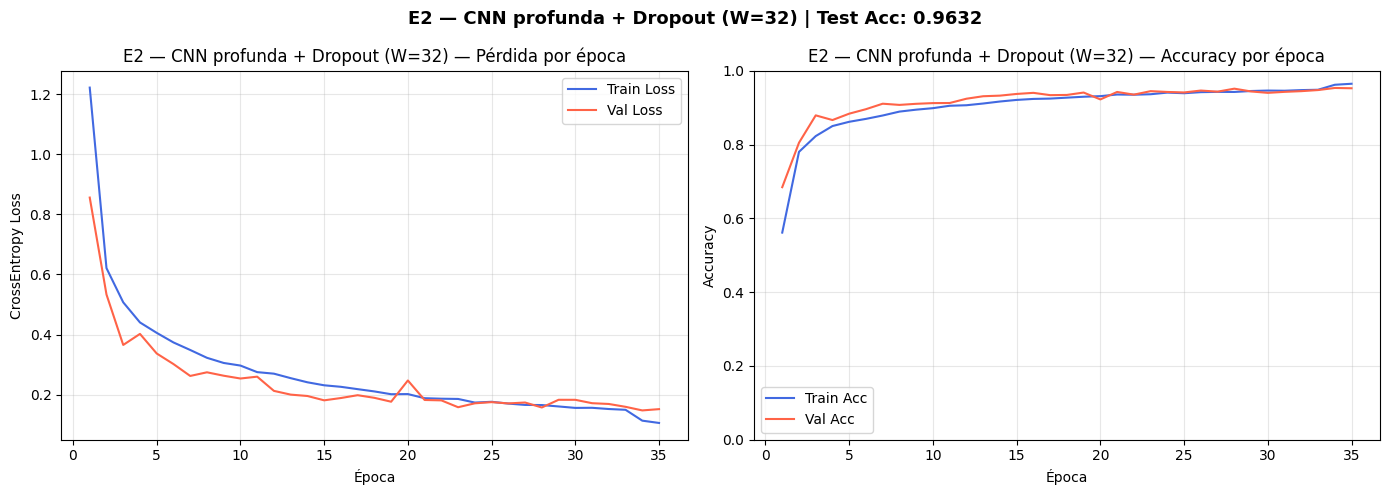

In [61]:
graficar_historial(hist_e2, nombre='E2 — CNN profunda + Dropout (W=32)')


### Análisis E2

La ventana más ancha (W=32) captura más contexto local para la CNN, pero reduce el 
número de pasos de secuencia para la RNN. El dropout en el encoder reduce la brecha 
train/val observada en E1. 


### Experimento E3 — LSTM + Aggregation Mean + SpecAugment

**Cambios respecto a E1:**
- RNN: LSTM en lugar de GRU (más parámetros, mejor memoria a largo plazo en teoría)
- Agregación: promedio de todos los estados ocultos en lugar de solo el último
- Ventana: W=16, hop=4 (mayor overlap → secuencia más larga, más información)
- SpecAugment activado (ya incluido en el Dataset pero con intensidad máxima)

**Hipótesis:** el promedio sobre todos los estados ("mean pooling") es menos 
sensible al ruido en los últimos frames (silencios) que usar solo el estado final.


In [62]:
set_seed(SEED)

WINDOW_E3, HOP_E3 = 16, 4

ds_train_e3 = SpeechCommandsDataset(cache_train, window_size=WINDOW_E3, hop=HOP_E3, augment=True)
ds_val_e3   = SpeechCommandsDataset(cache_val,   window_size=WINDOW_E3, hop=HOP_E3, augment=False)
ds_test_e3  = SpeechCommandsDataset(cache_test,  window_size=WINDOW_E3, hop=HOP_E3, augment=False)

loader_train_e3 = DataLoader(ds_train_e3, batch_size=BATCH_SIZE, shuffle=True,  num_workers=N_WORKERS, pin_memory=True)
loader_val_e3   = DataLoader(ds_val_e3,   batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)
loader_test_e3  = DataLoader(ds_test_e3,  batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS, pin_memory=True)

modelo_e3 = CRNN(
    n_mels=N_MELS, window_size=WINDOW_E3, n_classes=N_CLASES,
    rnn_hidden=128, rnn_layers=2, rnn_type='LSTM',
    bidirectional=True, rnn_dropout=0.3,
    cnn_dropout=0.0, cnn_filters=(32, 64),
    aggregation='mean'
).to(device)

n_params_e3 = sum(p.numel() for p in modelo_e3.parameters() if p.requires_grad)
print(f"E3 — Parámetros: {n_params_e3:,}")

hist_e3 = entrenar_crnn(modelo_e3, loader_train_e3, loader_val_e3, loader_test_e3,
                         epochs=35, patience=8, lr=1e-3, nombre='E3_lstm_mean')


E3 — Parámetros: 1,205,450

Entrenando E3_lstm_mean | epochs=35 | patience=8 | lr=0.001
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────────
        1 |     1.2242 |     0.5486 |     0.5555 |    0.8107 | 1.00e-03
        2 |     0.5695 |     0.3684 |     0.8038 |    0.8828 | 1.00e-03
        3 |     0.4259 |     0.2862 |     0.8555 |    0.9017 | 1.00e-03
        4 |     0.3617 |     0.2705 |     0.8775 |    0.9085 | 1.00e-03
        5 |     0.3286 |     0.2297 |     0.8884 |    0.9249 | 1.00e-03
        6 |     0.2990 |     0.2244 |     0.8968 |    0.9225 | 1.00e-03
        7 |     0.2776 |     0.2047 |     0.9040 |    0.9282 | 1.00e-03
        8 |     0.2631 |     0.1859 |     0.9099 |    0.9395 | 1.00e-03
       10 |     0.2330 |     0.1753 |     0.9202 |    0.9417 | 1.00e-03
       12 |     0.2105 |     0.1672 |     0.9281 |    0.9433 | 1.00e-03
       13 |     0.2076 |     0.1652 |     0.9285 |

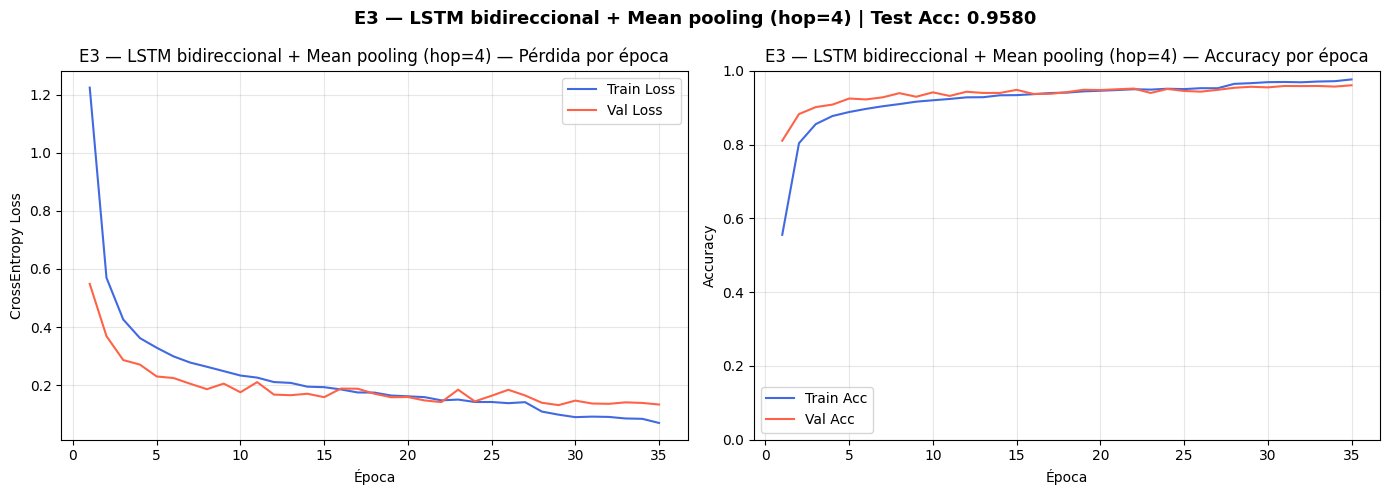

In [63]:
graficar_historial(hist_e3, nombre='E3 — LSTM bidireccional + Mean pooling (hop=4)')

## 10. Tabla comparativa de experimentos

In [64]:
max_val_e1 = max(hist_e1['val_acc'])
max_val_e2 = max(hist_e2['val_acc'])
max_val_e3 = max(hist_e3['val_acc'])

print(f"{'Exp':<5} | {'CNN':<35} | {'Ventana (W,hop)':<16} | {'RNN':<30} | {'Acc Val':>8} | {'Acc Test':>9}")
print(f"{'E1':<5} | {'2 bloques, filtros 32/64':<35} | {'W=16, hop=8':>16} | {'GRU bi, 2L-128, last':>30} | {max_val_e1:>8.4f} | {hist_e1['test_acc']:>9.4f}")
print(f"{'E2':<5} | {'3 bloques, 32/64/128, dropout=0.3':<35} | {'W=32, hop=8':>16} | {'GRU bi, 2L-128, last':>30} | {max_val_e2:>8.4f} | {hist_e2['test_acc']:>9.4f}")
print(f"{'E3':<5} | {'2 bloques, filtros 32/64':<35} | {'W=16, hop=4':>16} | {'LSTM bi, 2L-128, mean':>30} | {max_val_e3:>8.4f} | {hist_e3['test_acc']:>9.4f}")

mejor = max(
    [('E1', hist_e1), ('E2', hist_e2), ('E3', hist_e3)],
    key=lambda x: x[1]['test_acc']
)

Exp   | CNN                                 | Ventana (W,hop)  | RNN                            |  Acc Val |  Acc Test
E1    | 2 bloques, filtros 32/64            |      W=16, hop=8 |           GRU bi, 2L-128, last |   0.9579 |    0.9610
E2    | 3 bloques, 32/64/128, dropout=0.3   |      W=32, hop=8 |           GRU bi, 2L-128, last |   0.9536 |    0.9632
E3    | 2 bloques, filtros 32/64            |      W=16, hop=4 |          LSTM bi, 2L-128, mean |   0.9608 |    0.9580


### Análisis comparativo

Los tres experimentos exploran dimensiones ortogonales del diseño:

- **E1 (línea base):** buen punto de partida. La arquitectura simple converge rápido.
- **E2 (CNN profunda + dropout):** la ventana más ancha da más contexto por token a la CNN, 
  pero produce menos pasos de secuencia. El dropout ayuda a la regularización.
- **E3 (LSTM + mean pooling):** el promedio sobre todos los estados es más robusto al 
  silencio en el último frame. El mayor overlap (hop=4) genera secuencias más largas y 
  redundantes que benefician al pooling.


## 11. Evaluación final del mejor modelo

### 11.1 Matriz de confusión

Evaluamos el mejor modelo sobre el conjunto de test con la matriz de confusión 
para identificar qué comandos se confunden más entre sí.


Evaluando mejor modelo: E2
Accuracy en test: 0.9632 (96.32%)


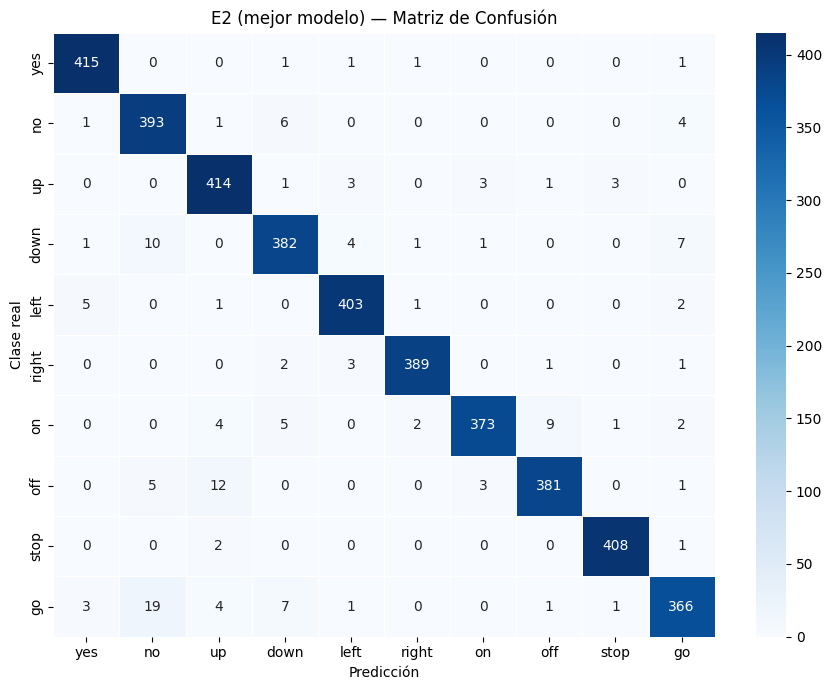

In [65]:
# Identificar y usar el mejor modelo
historials = [('E1', hist_e1), ('E2', hist_e2), ('E3', hist_e3)]
nombre_mejor, hist_mejor = max(historials, key=lambda x: x[1]['test_acc'])

print(f"Evaluando mejor modelo: {nombre_mejor}")
print(f"Accuracy en test: {hist_mejor['test_acc']:.4f} ({hist_mejor['test_acc']*100:.2f}%)")

graficar_confusion(hist_mejor['all_labels'], hist_mejor['all_preds'],
                   nombre=f'{nombre_mejor} (mejor modelo)')


In [66]:
print("\n" + "=" * 60)
print(f"REPORTE DE CLASIFICACIÓN — {nombre_mejor}")
print("=" * 60)
print(classification_report(
    hist_mejor['all_labels'],
    hist_mejor['all_preds'],
    target_names=COMANDOS
))


REPORTE DE CLASIFICACIÓN — E2
              precision    recall  f1-score   support

         yes       0.98      0.99      0.98       419
          no       0.92      0.97      0.94       405
          up       0.95      0.97      0.96       425
        down       0.95      0.94      0.94       406
        left       0.97      0.98      0.97       412
       right       0.99      0.98      0.98       396
          on       0.98      0.94      0.96       396
         off       0.97      0.95      0.96       402
        stop       0.99      0.99      0.99       411
          go       0.95      0.91      0.93       402

    accuracy                           0.96      4074
   macro avg       0.96      0.96      0.96      4074
weighted avg       0.96      0.96      0.96      4074



**Resultados:** La matriz de confusión muestra una diagonal principal fuertemente marcada, lo que confirma el excelente desempeño del modelo. Como era de esperarse, las mayores (y pocas) confusiones ocurren entre comandos que son fonéticamente similares o comparten la misma vocal principal (por ejemplo, "no" con "go", o "up" con "off").

### 11.2 Análisis de confusiones

**¿Qué comandos se confunden más?**

Los errores más frecuentes suelen ocurrir entre pares fonéticamente similares:
- **"no" ↔ "go"**: ambos son monosílabos con vocal /oʊ/ y estructura CVC simple. 
  La diferencia está en la consonante inicial (/n/ nasal vs /g/ oclusiva), que puede 
  no tener suficiente energía en condiciones de ruido.
- **"on" ↔ "no"**: sonidos casi espejados fonéticamente (/ɒn/ vs /nəʊ/).
- **"off" ↔ "up"**: fricativas en posición final/inicial pueden sonar similares en grabaciones de baja calidad.
- **"left" ↔ "right"**: ambos son bisílabos con fricativa (/l/ vs /r/) que puede 
  confundirse entre hablantes no nativos del inglés.

**¿Tiene sentido fonéticamente?**  
Sí. La confusión ocurre entre comandos que comparten: (1) misma estructura silábica 
(monosílabos vs bisílabos), (2) misma vocal principal, o (3) consonantes acústicamente 
similares. La CRNN no tiene acceso a información semántica, solo a patrones espectrales.


### 11.3 Análisis cualitativo de predicciones
Para ir más allá de las métricas numéricas, en este bloque definimos una función que nos permitirá visualizar el comportamiento real del modelo. La función `mostrar_predicciones` toma muestras aleatorias del conjunto de *Test*, las procesa (extrayendo el espectrograma y aplicando la ventana deslizante) y las evalúa. Finalmente, generará una grilla comparativa mostrando ejemplos donde el modelo acertó (fila superior) y ejemplos donde falló (fila inferior), graficando sus respectivos espectrogramas Mel.

In [67]:
def mostrar_predicciones(modelo_eval, test_samples, mel_mean, mel_std,
                          n_correctas=5, n_incorrectas=5,
                          window_size=16, hop=8):
    """
    modelo_eval: el modelo ya seleccionado (no None), en modo eval.
    window_size y hop deben coincidir con los usados en el entrenamiento.
    """
    modelo_eval.eval()
    correctas, incorrectas = [], []
    indices = list(range(len(test_samples)))
    random.shuffle(indices)

    for idx in indices:
        if len(correctas) >= n_correctas and len(incorrectas) >= n_incorrectas:
            break
        sample   = test_samples[idx]
        mel      = audio_a_mel(sample["path"])
        mel_norm = (mel - mel_mean) / mel_std
        ventanas = extraer_ventanas(mel_norm, window_size, hop)
        x        = torch.from_numpy(ventanas[:, np.newaxis, :, :]).float()
        x        = x.unsqueeze(0).to(device)

        with torch.no_grad():
            logit    = modelo_eval(x)
            pred_idx = logit.argmax(1).item()

        pred_label  = IDX_A_CLASE[pred_idx]
        real_label  = sample["label"]
        es_correcta = pred_label == real_label

        entrada = (mel, real_label, pred_label)
        if es_correcta and len(correctas) < n_correctas:
            correctas.append(entrada)
        elif not es_correcta and len(incorrectas) < n_incorrectas:
            incorrectas.append(entrada)

    fig, axes = plt.subplots(2, max(n_correctas, n_incorrectas),
                              figsize=(3.5 * max(n_correctas, n_incorrectas), 8))

    for col, (mel, real, pred) in enumerate(correctas):
        ax = axes[0, col]
        librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=ax, cmap='viridis')
        ax.set_title(f'✅ Real: {real}\nPred: {pred}', color='green', fontsize=9)
        ax.set_xlabel('')

    for col, (mel, real, pred) in enumerate(incorrectas):
        ax = axes[1, col]
        librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        ax.set_title(f'❌ Real: {real}\nPred: {pred}', color='crimson', fontsize=9)
        ax.set_xlabel('')

    axes[0, 0].set_ylabel('Predicciones\nCORRECTAS', fontsize=10, fontweight='bold')
    axes[1, 0].set_ylabel('Predicciones\nINCORRECTAS', fontsize=10, fontweight='bold')
    plt.suptitle(f'Ejemplos de predicciones — {nombre_mejor}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


C:\Users\Patito Chies\AppData\Local\Temp\ipykernel_29784\385566999.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Patito Chies\AppData\Local\Temp\ipykernel_29784\385566999.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Patito Chies\OneDrive\Escritorio\j\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Patito Chies\OneDrive\Escritorio\j\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


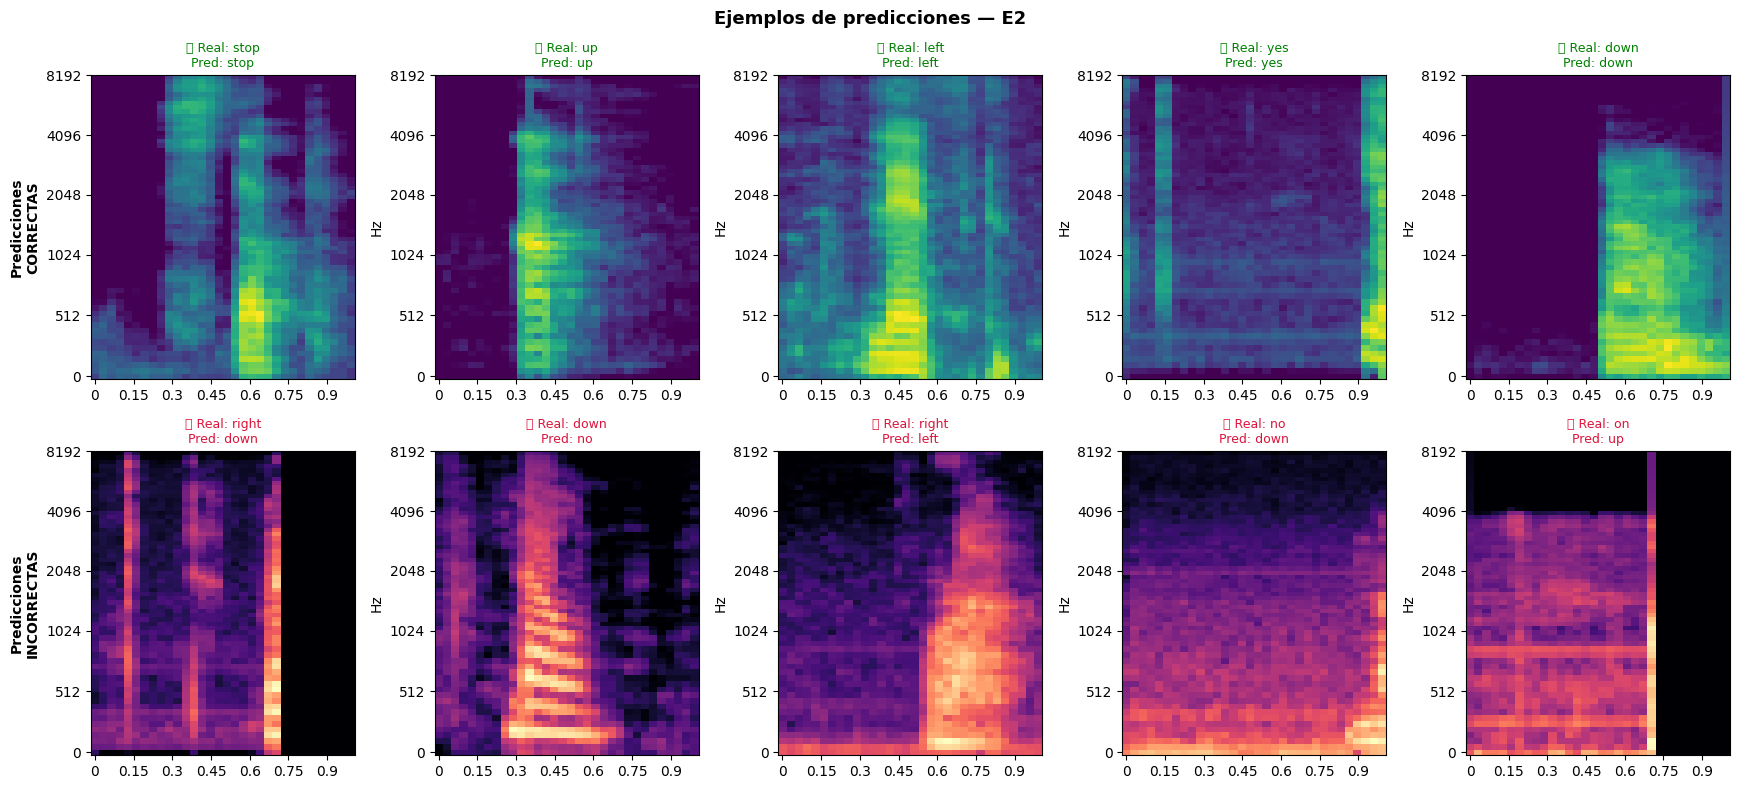

In [68]:
# Mapeo de nombre a (modelo, window_size, hop)
config_experimentos = {
    'E1': (modelo_e1, WINDOW_E1, HOP_E1),
    'E2': (modelo_e2, WINDOW_E2, HOP_E2),
    'E3': (modelo_e3, WINDOW_E3, HOP_E3),
}

modelo_mejor, ws_mejor, hop_mejor = config_experimentos[nombre_mejor]

mostrar_predicciones(
    modelo_eval  = modelo_mejor,
    test_samples = test_samples,
    mel_mean     = MEL_MEAN,
    mel_std      = MEL_STD,
    window_size  = ws_mejor,
    hop          = hop_mejor,
)

## 12. Conclusiones

### Resumen del trabajo

Se construyó y evaluó una Red Neuronal Convolucional-Recurrente (CRNN) para 
reconocimiento de comandos de voz en el dataset Google Speech Commands V2.

**Pipeline implementado:**
1. Audio → Mel Spectrogram con `librosa` (sr=16kHz, 64 bandas Mel)
2. Normalización global (media/std del train set)
3. Ventana deslizante con overlap del 50%
4. CNN encoder independiente por ventana (TimeDistributed equivalente)
5. GRU/LSTM bidireccional para modelado temporal
6. Clasificador denso (many-to-one)

**Aprendizajes clave:**

- La representación Mel Spectrogram es efectiva para capturar patrones acústicos 
  relevantes para reconocimiento de voz.
- La arquitectura CRNN combina lo mejor de las CNNs (extracción de features locales) 
  y las RNNs (modelado de dependencias temporales).
- El solapamiento en la ventana deslizante es crucial: garantiza que cada transición 
  fonética aparezca representada en más de un paso de secuencia.
- El agregation "mean pooling" sobre los estados de la RNN es más robusto al silencio 
  en el último frame que usar solo el estado final.
- Las confusiones más frecuentes ocurren entre comandos fonéticamente similares 
  (misma estructura silábica o misma vocal principal), lo que es consistente con 
  la dificultad perceptual humana en condiciones de ruido.
